In [26]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps



In [27]:
#settings
N = 5  # Number of variables
F = 8  # Forcing
start = F * np.ones(N)  # Initial state (equilibrium)
start[0] += 0.01  # Add small perturbation to the first variable
dt = 0.01
subset_size = 100#50#cell number
traj_length = int(1e6)#length of trajectory
noise_level = 0.2#.2#.3
sample_size = int(5000)
slope = 0.1
sampling_time = 1
simulation_t = int(5e3)
steps = 5
def L96(x, t):
    """Lorenz 96 model with constant forcing"""
    return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - x + F 


t = np.arange(0.0, traj_length*dt, dt)



In [28]:
trajectory_clean = scipy.integrate.odeint(L96, start, t)

In [29]:
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,5)))#loooooooong trajectory
trajectory = trajectory[int(1e3):][::sampling_time]

#uniformly random data
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,5)))#loooooooong trajectory
trajectory = trajectory[int(1e3):]
rand_idxs = np.random.choice(len(trajectory), size=sample_size, replace=False)
observed = trajectory[rand_idxs]
randpts = torch.tensor(trajectory[rand_idxs],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_idxs+steps],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()
class W2Loss(torch.autograd.Function):
    @staticmethod
    def forward(ctx, U_net):
        U_net_np = U_net.detach().numpy()
        cost_cols,grad = np.zeros(subset_size),np.zeros((subset_size,subset_size))
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), np.arange(subset_size).reshape(-1, 1))
        for col in range(subset_size):
            _, log = ot.emd(U_true_np[:,col], U_net_np[:,col], costM, log=True)
            cost_cols[col],grad[col] = log['cost'],log["v"]
        loss,grad = np.sum(cost_cols),grad.T
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)

/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


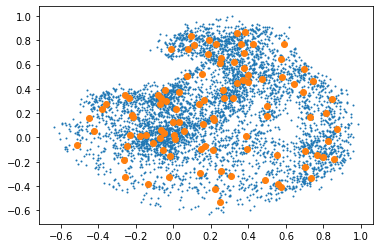

In [30]:
plt.scatter(randpts[:,0],randpts[:,1],s = 1)
plt.scatter(Voronoi_centers[:,0],Voronoi_centers[:,1])

In [31]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 5))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
# optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
# net2.train()
N_iters = 50000

net1.train()
loss1 = []
#invert_variables = [0,1,2,3,4]
net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field = net1(net1_randpts)
    net1_randpts = net1_randpts + dt * V_field  # out-of-place update
U_net = Ulam(randpts, net1_randpts)
initial_L1 = W2Loss.apply(U_net)

Iteration 0, Loss(Ours): 1.6140327453613281


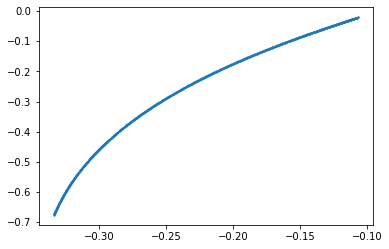

Iteration 500, Loss(Ours): 0.053603723645210266
Iteration 1000, Loss(Ours): 0.02537309192121029
Early stopping at iteration 1000, Loss: 0.02537309192121029


In [32]:
for i in range(N_iters):
    optimizer1.zero_grad()
    net1_randpts = randpts
    for _ in range(steps):
        V_field = net1(net1_randpts)
        net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    #im_net = invariant_measure(U_net)
    #L1 = torch.linalg.matrix_norm(U_net - U_true,ord = 'fro')
    #L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
    L1 = W2Loss.apply(U_net)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())


    # Logging
    if i % 500 == 0:
        print(f'Iteration {i}, Loss(Ours): {L1.item()}')
        if L1.item() < 0.02 * initial_L1:
            print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
            break
    # Visualization every 5000 iterations
    if i % 5000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        vals1= [x1.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            #for j in range(steps):
            V_field = net1(x1)
            x1 = x1+dt* V_field
                
            vals1.append(x1.detach().numpy().flatten())

        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
        plt.show()
        # plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        # plt.show()

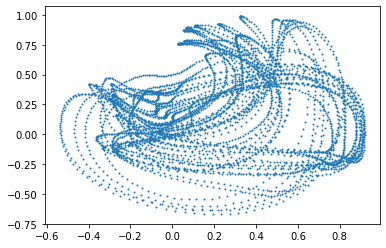

In [33]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):
    #for i in range(steps):
    V_field = net1(x1)
    x1 = x1+dt* V_field
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 1], s=1)

plt.show()

In [41]:
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 5))


optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()


loss2 = []

net2_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field2 = net2(net2_randpts)
    net2_randpts = net2_randpts + dt * V_field2  # out-of-place update
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)

Iteration 0, Loss(Pointwise): 0.009109102189540863


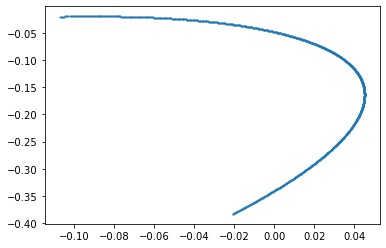

Iteration 500, Loss(Pointwise): 0.0007084657554514706
Iteration 1000, Loss(Pointwise): 0.0006705299601890147
Iteration 1500, Loss(Pointwise): 0.0006421591970138252
Iteration 2000, Loss(Pointwise): 0.0006151701090857387
Iteration 2500, Loss(Pointwise): 0.0005905443686060607
Iteration 3000, Loss(Pointwise): 0.0005662221228703856
Iteration 3500, Loss(Pointwise): 0.0005413252511061728
Iteration 4000, Loss(Pointwise): 0.0005157335544936359
Iteration 4500, Loss(Pointwise): 0.0004896646132692695
Iteration 5000, Loss(Pointwise): 0.00046326321898959577


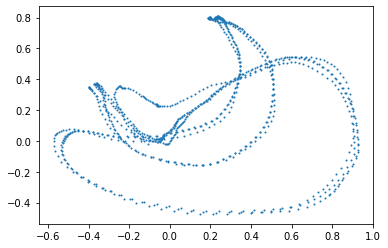

Iteration 5500, Loss(Pointwise): 0.0004366926150396466
Iteration 6000, Loss(Pointwise): 0.0004119286313652992
Iteration 6500, Loss(Pointwise): 0.0003884999023284763
Iteration 7000, Loss(Pointwise): 0.00036638783058151603
Iteration 7500, Loss(Pointwise): 0.0003457160491961986
Iteration 8000, Loss(Pointwise): 0.0003269747248850763
Iteration 8500, Loss(Pointwise): 0.0003102787013631314
Iteration 9000, Loss(Pointwise): 0.0002953286748379469
Iteration 9500, Loss(Pointwise): 0.0002820045338012278
Iteration 10000, Loss(Pointwise): 0.00027018808759748936


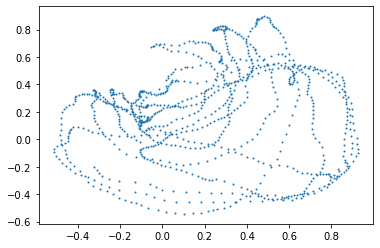

Iteration 10500, Loss(Pointwise): 0.0002593190874904394
Iteration 11000, Loss(Pointwise): 0.00025009113596752286
Iteration 11500, Loss(Pointwise): 0.00024162346380762756
Iteration 12000, Loss(Pointwise): 0.00023334888101089746
Iteration 12500, Loss(Pointwise): 0.00022576293849851936
Iteration 13000, Loss(Pointwise): 0.000220152287511155
Iteration 13500, Loss(Pointwise): 0.00021470697538461536
Iteration 14000, Loss(Pointwise): 0.00020884122932329774
Iteration 14500, Loss(Pointwise): 0.0002041658153757453
Iteration 15000, Loss(Pointwise): 0.0001999490923481062


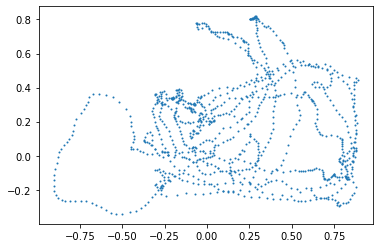

Iteration 15500, Loss(Pointwise): 0.000196689143194817
Iteration 16000, Loss(Pointwise): 0.00019292118668090552
Iteration 16500, Loss(Pointwise): 0.0001889698760351166
Iteration 17000, Loss(Pointwise): 0.000186194185516797
Iteration 17500, Loss(Pointwise): 0.00018315709894523025
Iteration 18000, Loss(Pointwise): 0.00018061172158923
Early stopping at iteration 18000, Loss: 0.00018061172158923


In [42]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()
    # optimizer2.zero_grad()
    
    # Update for net1 (Ulam)
    # net1_randpts = net1(randpts) #parametrize the map

    
    net2_randpts = randpts
    for _ in range(steps):
        V_field2 = net2(net2_randpts)
        net2_randpts = net2_randpts+dt* V_field2


    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    

    # Logging
    if i % 500 == 0:
        print(f'Iteration {i}, Loss(Pointwise): {L2.item()}')
        if L2.item() < 0.02 * initial_L2:
            print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
            break
        
    # Visualization
    if i % 5000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        vals2 = [x2.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            #for j in range(steps):

            V_field2 = net2(x2)
            x2 = x2 + V_field2*dt
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        plt.show()

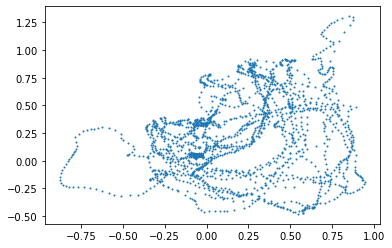

In [43]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    #for j in range(steps):

    V_field2 = net2(x2)
    x2 = x2 + V_field2*dt
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
plt.show()

In [44]:
GT = scipy.integrate.odeint(L96, M_scale*randpts[0], np.arange(0.0, simulation_t*dt, dt))#[::steps]

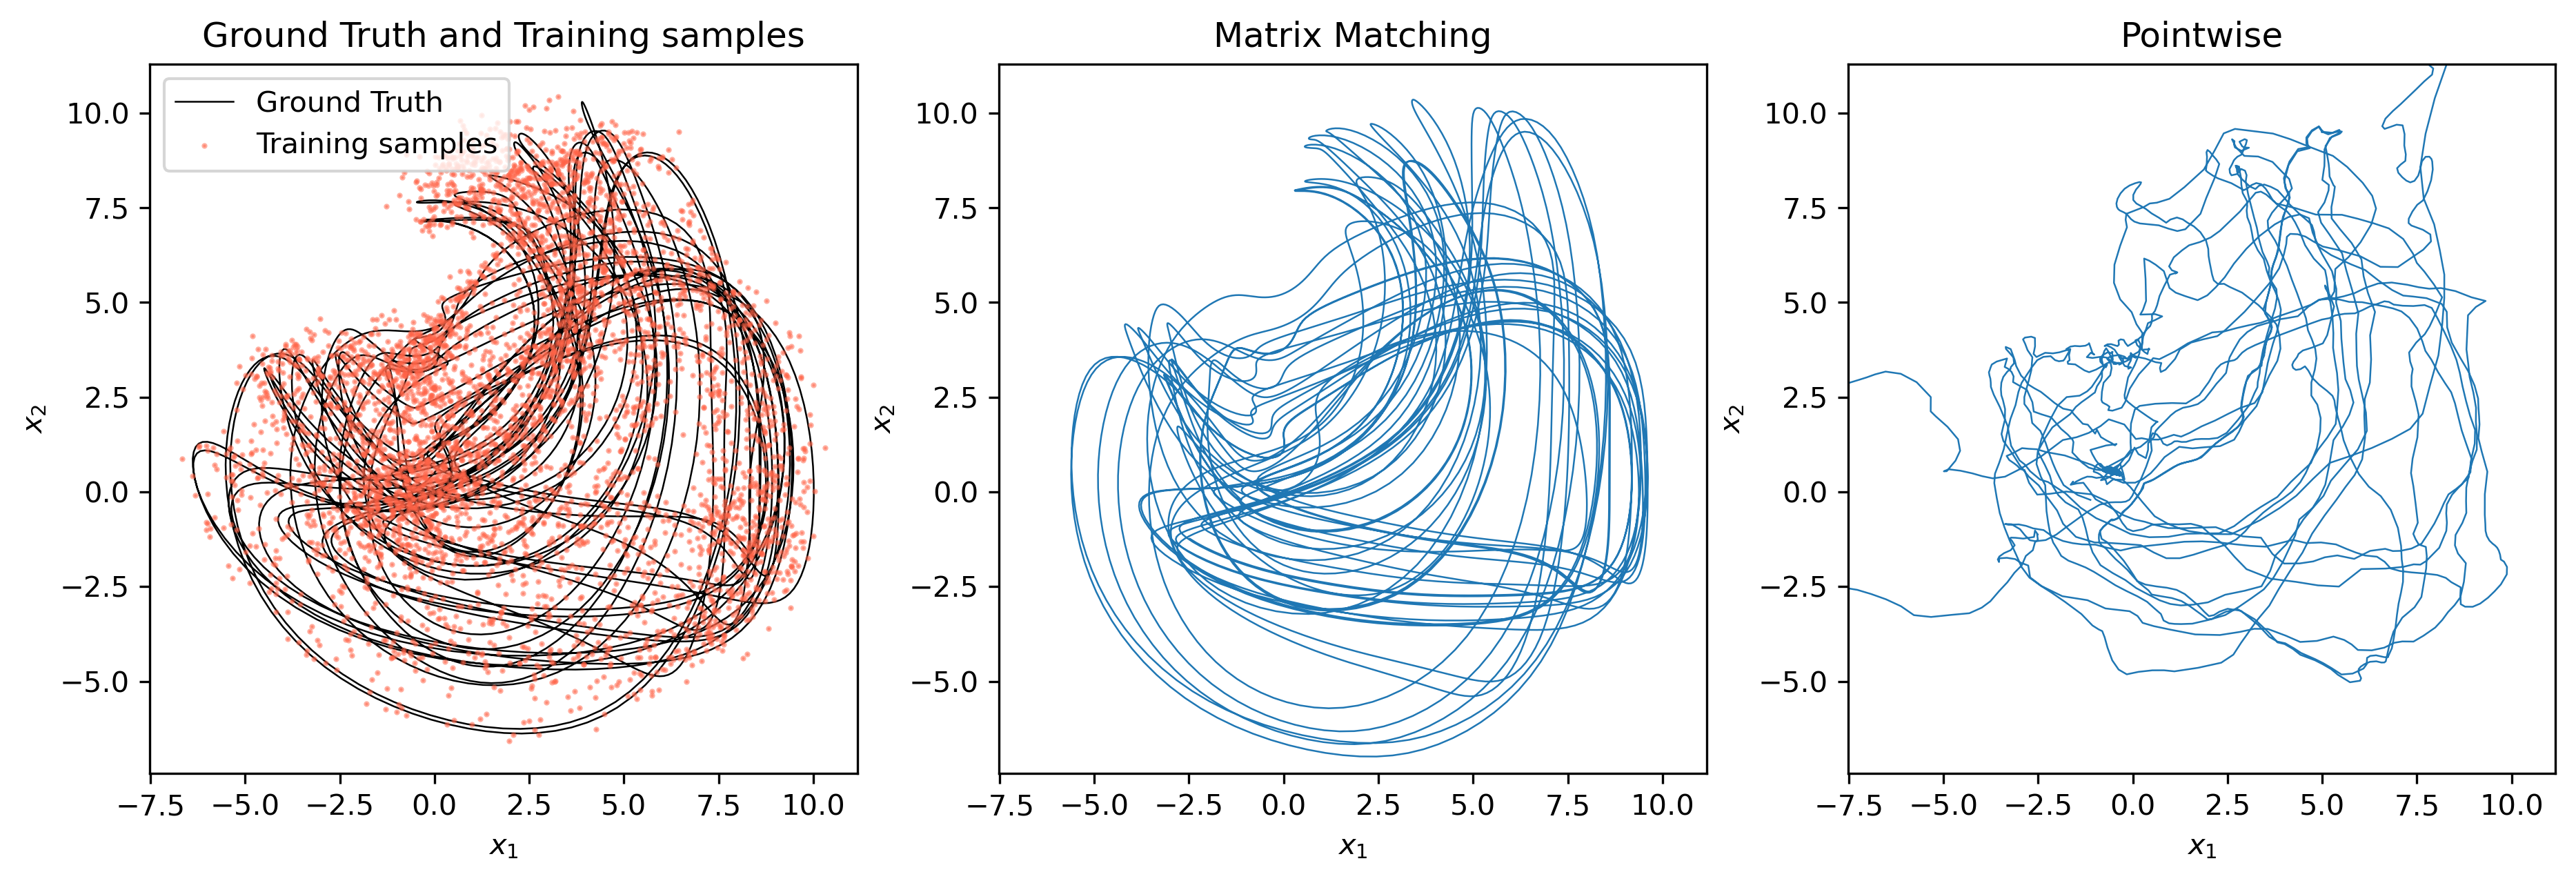

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 1], linewidth=0.6)
axes[1].set_title('Matrix Matching')

# Plot vals_ode (neural ODE results)
axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 1], linewidth=0.6)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory
axes[0].plot(GT[:, 0], GT[:, 1], label="Ground Truth", linewidth=0.6, zorder=1, c = "black")
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 1], s=1, c="tomato", alpha = 0.5,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')

# Set axis labels and layout
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()


for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')

#fig.text(0.04, 0.5, 'Lorenz-96', va='center', rotation='vertical', fontsize=14)
#plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()